# Examples using the STAC-based interface to _NatureDataCube_

**Author:** Bruno Marcos

**Created in:** March 23, 2026

**Last modified in:** June 4, 2026

[1] "/tmp/RtmprdIPqN"


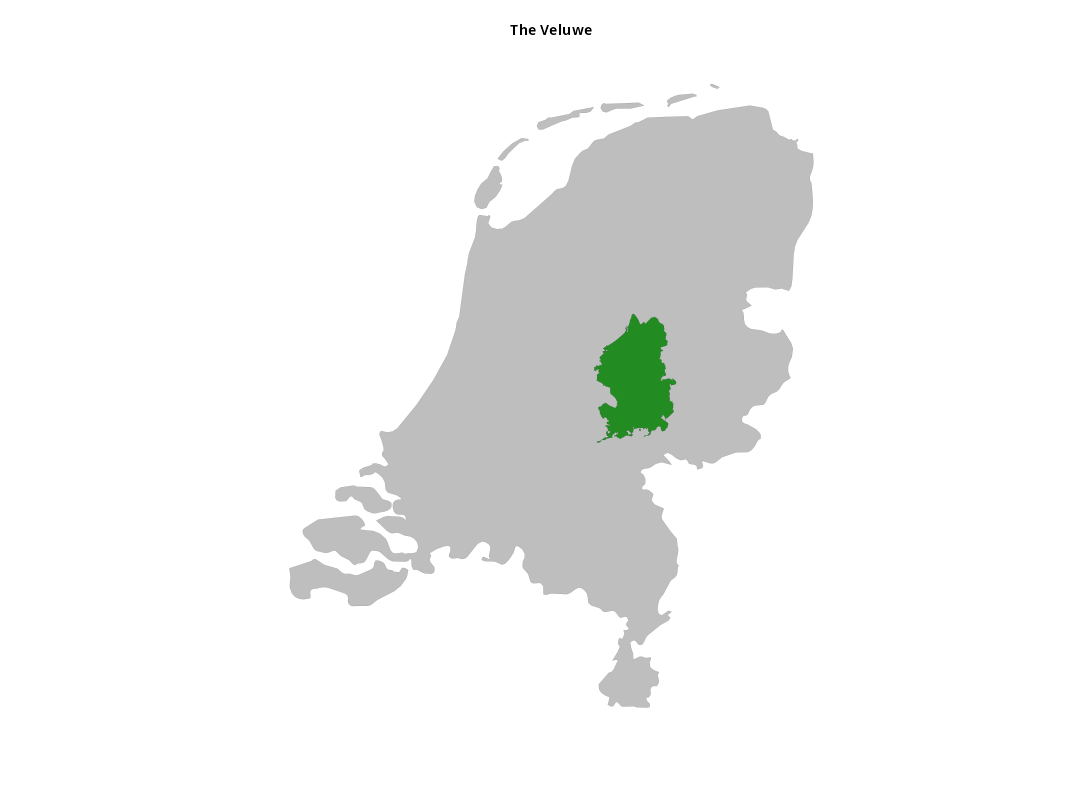

In [5]:
# Load packages
pkgs <- c("rstac", "httr", "sf", "lubridate", "terra", "rNDC")
pkgs |>
  lapply(FUN = library, character.only = TRUE) |>
  invisible() |>
  suppressPackageStartupMessages()

# Define parameters
mytoken <- Sys.getenv("NDC_TOKEN")
headers <- add_headers("Authorization" = paste0("Bearer ", mytoken))
endpoint <- "https://ndc.wur.nl/api/"

# Define dates
date_rcf3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")
startdate <- "2026-04-15"
enddate <- "2026-05-13"
daterange <- paste(lapply(c(startdate, enddate), FUN = date_rcf3339), collapse = "/")

# Define output directory
tmp <- tempdir()
print(tmp)

# Import region-of-interest
nl <- st_read("../inst/extdata/nl.gpkg", quiet = TRUE) |>
  st_as_sf() |>
  st_transform(4326) |>
  st_geometry()
veluwe <- st_read("../inst/extdata/veluwe.gpkg", quiet = TRUE) |>
  st_as_sf() |>
  st_transform(4326) |>
  st_geometry()
plot(nl, col = "grey", lwd = 0.1, main = "The Veluwe")
plot(veluwe, col = "forestgreen", lwd = 0.1, add = TRUE)

## 1. Endpoint

### 1.1. Check endpoint catalog info

In [6]:
ep <- stac(endpoint)

In [7]:
get_request(ep)

###STACCatalog
- id: naturedatacube-stac-api
- description: 
Geodata for Dutch nature areas, served through a STAC-native API: LTER research site and SNL nature parcel boundaries, Sentinel-2 NDVI and true-colour rasters from GroenMonitor, LGN land use, soil maps (Bodemkaart) and RIVM nitrogen products, plus yearly per-parcel statistics. Collections are grouped into the thematic catalogs below and work out of the box in QGIS, ArcGIS Pro, pystac and any other STAC client.

Browsing the catalogs is open to everyone; accessing collections and items requires a free API token: [request one at ndc.wur.nl/register](https://ndc.wur.nl/register). More about the platform: [ndc.wur.nl](https://ndc.wur.nl/). NatureDataCube is developed by Wageningen Environmental Research as part of LTER-LIFE.
- field(s): 
type, id, title, description, stac_version, conformsTo, links, stac_extensions, stac_browser

### 1.2. Check endpoint conformance info

In [8]:
ep |>
  conformance() |>
  get_request()

###Conformance
- conformsTo: 
  - http://www.opengis.net/spec/cql2/1.0/conf/basic-cql2
  - http://www.opengis.net/spec/cql2/1.0/conf/cql2-json
  - http://www.opengis.net/spec/cql2/1.0/conf/cql2-text
  - http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/core
  - http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/geojson

### 1.3. List catalog queryables

In [41]:
ep |>
  queryables() |>
  get_request(headers)

###Queryables
- properties
  - collection
  - datetime
  - geometry
  - id
- field(s): $schema, $id, type, title, description, properties, additionalProperties

## 2. Collections

### 2.1. List all collections within the endpoint

In [16]:
ep |>
  collections() |>
  get_request(headers)

###STACCollectionList
- collections (21 item(s)):
  - lter
  - snl
  - ndvi-lter
  - ndvi-snl
  - soiltypes-lter
  - soiltypes-snl
  - lgn-lter
  - lgn-snl
  - soiltypes
  - ndvi
  - ... with 11 more collection(s).
- field(s): collections, links, numberMatched, numberReturned

### 2.2. Check collection info

_2.2.1. LTER vector features_

In [10]:
ep |>
  collections(collection_id = "lter") |>
  get_request(headers)

###STACCollection
- id: lter
- title: LTER
- description: 
Long-Term Ecosystem Research (LTER-NL) site boundaries used as reference parcels for ecological monitoring in NatureDataCube.
- field(s): 
id, type, links, title, extent, license, keywords, description, stac_version

_2.2.2. NDVI zonal statistics for the LTER vector features_

In [11]:
ep |>
  collections(collection_id = "ndvi-lter") |>
  get_request(headers)

###STACCollection
- id: ndvi-lter
- title: NDVI LTER
- description: 
NDVI zonal statistics for source LTER, linked to parcel geometries from collection 'lter'.
- field(s): 
id, type, links, title, extent, license, keywords, description, stac_version

_2.2.3. SNL_

In [12]:
ep |>
  collections(collection_id = "snl") |>
  get_request(headers)

###STACCollection
- id: snl
- title: SNL
- description: 
Dutch SNL (Subsidiestelsel Natuur en Landschap) management-unit boundaries used as reference parcels for nature and landscape monitoring in NatureDataCube.
- field(s): 
id, type, links, title, extent, license, keywords, description, stac_version

_2.2.4. NDVI zonal statistics for the SNL vector features_

In [13]:
ep |>
  collections(collection_id = "ndvi-snl") |>
  get_request(headers)

###STACCollection
- id: ndvi-snl
- title: NDVI SNL
- description: 
NDVI zonal statistics for source SNL, linked to parcel geometries from collection 'snl'.
- field(s): 
id, type, links, title, extent, license, keywords, description, stac_version

_2.2.5. NDVI raster layers_

In [17]:
ep |>
  collections(collection_id = "ndvi") |>
  get_request(headers)

###STACCollection
- id: ndvi
- title: Sentinel-2 NDVI Rasters
- description: 
Preprocessed NDVI (Normalized Difference Vegetation Index) rasters from Sentinel-2 imagery for the Netherlands, from [GroenMonitor](https://www.groenmonitor.nl/). One item per acquisition date. Each discovered WMS layer is exposed as one STAC item with WMS/WCS links, legend metadata, and preview assets for API-driven workflows.
- field(s): 
id, type, links, title, assets, extent, license, keywords, providers, summaries, description, stac_version

_2.2.6. Land use/cover_

In [18]:
ep |>
  collections(collection_id = "lgn") |>
  get_request(headers)

###STACCollection
- id: lgn
- title: Land Use Classification (LGN)
- description: 
Land use classification rasters from the Landelijk Grondgebruiksbestand Nederland (LGN). Holds one item per LGN year; future years are added to this collection. Published on NDC GeoServer as item-level STAC records: each item includes WMS preview and legend assets for direct visualization, plus a WCS GetCoverage link for raster download workflows.
- field(s): 
id, type, links, title, assets, extent, license, keywords, providers, summaries, description, stac_version

_2.2.7. Soil types_

In [19]:
ep |>
  collections(collection_id = "soiltypes") |>
  get_request(headers)

###STACCollection
- id: soiltypes
- title: Soil Types (Bodemkaart)
- description: 
Dutch soil map (Bodemkaart) rasters with soil type classification for the Netherlands. Published on NDC GeoServer as item-level STAC records: each item includes WMS preview and legend assets for direct visualization, plus a WCS GetCoverage link for raster download workflows.
- field(s): 
id, type, links, title, assets, extent, license, keywords, providers, summaries, description, stac_version

## 3. Items

### 3.1. List all items within a collection

In [22]:
ep |>
  collections(collection_id = "ndvi") |>
  items(limit = 1000) |>
  get_request(headers)

###STACItemCollection
- matched feature(s): 293
- features (293 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260826
  - gm-groenmonitor__ndvi_20260814
  - gm-groenmonitor__ndvi_20260812
  - gm-groenmonitor__ndvi_20260809
  - gm-groenmonitor__ndvi_20260804
  - gm-groenmonitor__ndvi_20260728
  - gm-groenmonitor__ndvi_20260725
  - gm-groenmonitor__ndvi_20260713
  - gm-groenmonitor__ndvi_20260625
  - gm-groenmonitor__ndvi_20260620
  - ... with 283 more feature(s).
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type

### 3.2. List items that intersect a given polygon

In [23]:
ep |>
  stac_search(collections = "ndvi",
              intersects = veluwe,
              limit = 1000) |>
  post_request(headers)

###STACItemCollection
- matched feature(s): 293
- features (293 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260826
  - gm-groenmonitor__ndvi_20260814
  - gm-groenmonitor__ndvi_20260812
  - gm-groenmonitor__ndvi_20260809
  - gm-groenmonitor__ndvi_20260804
  - gm-groenmonitor__ndvi_20260728
  - gm-groenmonitor__ndvi_20260725
  - gm-groenmonitor__ndvi_20260713
  - gm-groenmonitor__ndvi_20260625
  - gm-groenmonitor__ndvi_20260620
  - ... with 283 more feature(s).
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type

### 3.3. List items for a specified time window

In [24]:
ep |>
  stac_search(collections = "ndvi",
              intersects = veluwe,
              datetime = daterange,
              limit = 100) |>
  post_request(headers)

###STACItemCollection
- matched feature(s): 4
- features (4 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260508
  - gm-groenmonitor__ndvi_20260501
  - gm-groenmonitor__ndvi_20260429
  - gm-groenmonitor__ndvi_20260421
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type

### 3.4. List items for a specific layer (using keywords)

In [26]:
ep |>
  stac_search(collections = "ndvi",
              intersects = veluwe,
              limit = 100) |>
  post_request(headers) |>
  items_filter("ndvi" %in% properties$`keywords`)

###STACItemCollection
- matched feature(s): 293
- features (100 item(s) / 193 not fetched):
  - gm-groenmonitor__ndvi_20260826
  - gm-groenmonitor__ndvi_20260814
  - gm-groenmonitor__ndvi_20260812
  - gm-groenmonitor__ndvi_20260809
  - gm-groenmonitor__ndvi_20260804
  - gm-groenmonitor__ndvi_20260728
  - gm-groenmonitor__ndvi_20260725
  - gm-groenmonitor__ndvi_20260713
  - gm-groenmonitor__ndvi_20260625
  - gm-groenmonitor__ndvi_20260620
  - ... with 90 more feature(s).
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type

### 3.5. Fetch items as a spatial object

In [51]:
myquery <- ep |>
  stac_search(collections = "ndvi",
              intersects = veluwe,
              datetime = daterange,
              limit = 100) |>
  post_request(headers)
print(myquery)

###STACItemCollection
- matched feature(s): 4
- features (4 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260508
  - gm-groenmonitor__ndvi_20260501
  - gm-groenmonitor__ndvi_20260429
  - gm-groenmonitor__ndvi_20260421
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


In [52]:
items_reap(myquery, field = c("properties", "datetime"))

[1] "2026-05-08T00:00:00Z" "2026-05-01T00:00:00Z" "2026-04-29T00:00:00Z" "2026-04-21T00:00:00Z"

In [53]:
myfetch <- items_fetch(myquery, progress = FALSE)

### 3.6. Filter items after fetching

In [54]:
items <- items_filter(myquery, "ndvi" %in% properties$`keywords`)
print(items)

###STACItemCollection
- matched feature(s): 4
- features (4 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260508
  - gm-groenmonitor__ndvi_20260501
  - gm-groenmonitor__ndvi_20260429
  - gm-groenmonitor__ndvi_20260421
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


In [55]:
items_as_sf(items)

Simple feature collection with 4 features and 12 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 2.999698 ymin: 50.66248 xmax: 7.340316 ymax: 53.60882
Geodetic CRS:  WGS 84
          title                                   description                       geometry
1 ndvi_20260508 GeoServer layer 'groenmonitor:ndvi_20260508'. POLYGON ((2.999698 50.66248...
2 ndvi_20260501 GeoServer layer 'groenmonitor:ndvi_20260501'. POLYGON ((2.999698 50.66248...
3 ndvi_20260429 GeoServer layer 'groenmonitor:ndvi_20260429'. POLYGON ((2.999698 50.66248...
4 ndvi_20260421 GeoServer layer 'groenmonitor:ndvi_20260421'. POLYGON ((2.999698 50.66248...
                  source             datetime geoserver:layer_name  geoserver:qualified_layer
1 groenmonitor-geoserver 2026-05-08T00:00:00Z        ndvi_20260508 groenmonitor:ndvi_20260508
2 groenmonitor-geoserver 2026-05-01T00:00:00Z        ndvi_20260501 groenmonitor:ndvi_20260501
3 groenmonitor-geoserver 2026-04-29T00:00:00Z        ndvi_2

## 4. Assets

### 4.1. Filter assets

In [ ]:
assets <- assets_select(items, asset_names = "download")
#assets <- assets_select(items, asset_names = "wcs")
print(assets)

###STACItemCollection
- matched feature(s): 4
- features (4 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260508
  - gm-groenmonitor__ndvi_20260501
  - gm-groenmonitor__ndvi_20260429
  - gm-groenmonitor__ndvi_20260421
- assets: download
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


### 4.2. List URLs for all matched assets

In [34]:
assets_url(assets)

[1] "https://data.groenmonitor.nl/geoserver/ows/groenmonitor__ndvi_20260508.tif?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor%3Andvi_20260508&format=image%2Ftiff"
[2] "https://data.groenmonitor.nl/geoserver/ows/groenmonitor__ndvi_20260501.tif?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor%3Andvi_20260501&format=image%2Ftiff"
[3] "https://data.groenmonitor.nl/geoserver/ows/groenmonitor__ndvi_20260429.tif?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor%3Andvi_20260429&format=image%2Ftiff"
[4] "https://data.groenmonitor.nl/geoserver/ows/groenmonitor__ndvi_20260421.tif?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor%3Andvi_20260421&format=image%2Ftiff"

### 4.3. Download selected assets

In [38]:
assets_dl <- assets_download(assets, output_dir = tmp, output_ext = ".tif", overwrite = TRUE)
print(assets_dl)

  |=====================================================================================| 100%
###STACItemCollection
- matched feature(s): 4
- features (4 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260508
  - gm-groenmonitor__ndvi_20260501
  - gm-groenmonitor__ndvi_20260429
  - gm-groenmonitor__ndvi_20260421
- assets: download
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


In [ ]:
#assets_dl <- assets_download_wcs(assets, output_dir = tmp, output_ext = ".tif", overwrite = TRUE)
#print(assets_dl)

### 4.4. List downloaded files

In [39]:
dl_files <- list.files(path = tmp,
                       pattern = "*.tif",
                       full.names = TRUE,
                       recursive = TRUE)
print(dl_files)

[1] "/tmp/RtmprdIPqN/geoserver/ows/groenmonitor__ndvi_20260421.tif"
[2] "/tmp/RtmprdIPqN/geoserver/ows/groenmonitor__ndvi_20260429.tif"
[3] "/tmp/RtmprdIPqN/geoserver/ows/groenmonitor__ndvi_20260501.tif"
[4] "/tmp/RtmprdIPqN/geoserver/ows/groenmonitor__ndvi_20260508.tif"


In [49]:
r <- rast(dl_files[-1])
names(r) <- paste("ndvi", c("pre", "during", "post"), sep = "_")
print(r)

class       : SpatRaster 
dimensions  : 31980, 28764, 3  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 499980, 787620, 5620200, 5940000  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
sources     : groenmonitor__ndvi_20260429.tif  
              groenmonitor__ndvi_20260501.tif  
              groenmonitor__ndvi_20260508.tif  
names       : ndvi_pre, ndvi_during, ndvi_post 


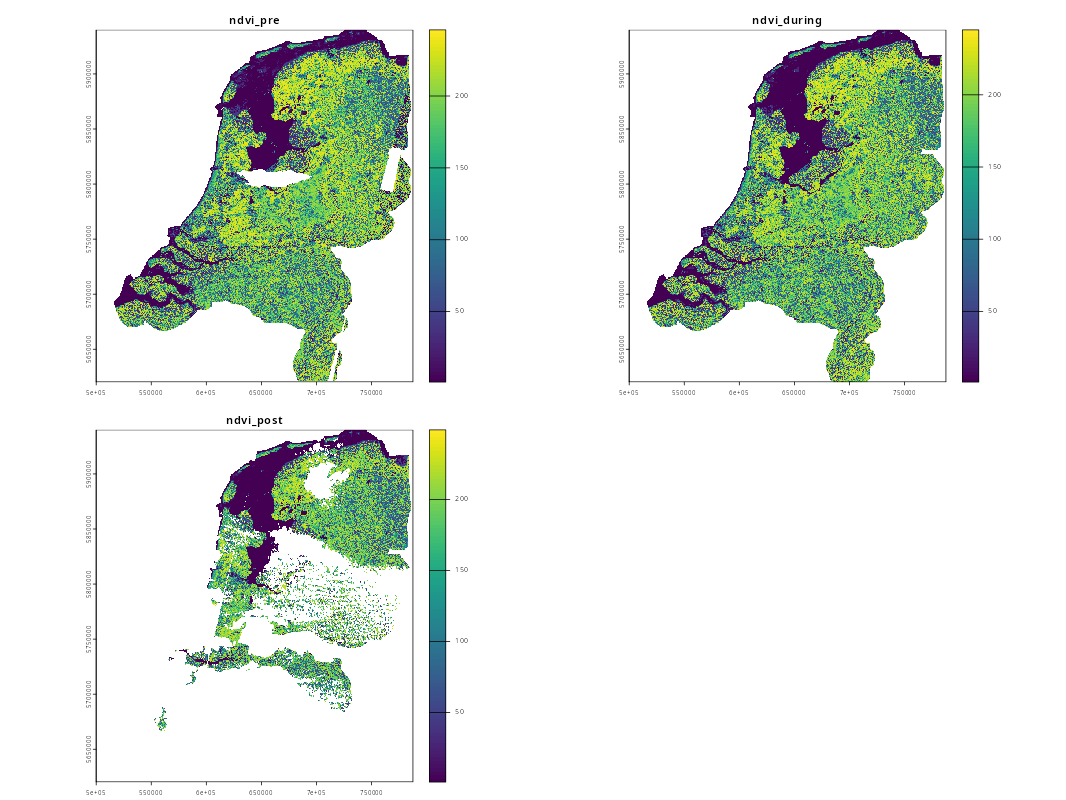

In [50]:
plot(r)